In [1]:
import pandas as pd 
from sentence_transformers import SentenceTransformer 
import numpy as np 
import os 
from dotenv import load_dotenv 
import hashlib
import matplotlib.pyplot as plt 
import pickle

FRED_API_KEY = os.getenv('FRED_API_KEY')

In [2]:
# load fomc statements from csv
df = pd.read_csv('fomc_statements.csv') 
df = df[::-1].reset_index(drop=True)
df.head()

,date,source,text
0,2006-01-31,html,"January 31, 2006\n\n\nFOMC statement\n\n\nFor ..."
1,2006-03-28,html,"March 28, 2006\n\n\nFOMC statement\n\n\nFor im..."
2,2006-05-10,html,"May 10, 2006\n\n\nFOMC statement and Board app..."
3,2006-06-29,html,"June 29, 2006\n\n\nFOMC statement\n\n\nFor imm..."
4,2006-08-08,html,"August 08, 2006\n\n\nFOMC statement\n\n\nFor i..."


In [3]:
print(
    ' '.join(
        df.head(1)['text']
          .item()
          .split()
    )
)

January 31, 2006 FOMC statement For immediate release Share The Federal Open Market Committee decided today to raise its target for the federal funds rate by 25 basis points to 4-1/2 percent. Although recent economic data have been uneven, the expansion in economic activity appears solid. Core inflation has stayed relatively low in recent months and longer-term inflation expectations remain contained. Nevertheless, possible increases in resource utilization as well as elevated energy prices have the potential to add to inflation pressures. The Committee judges that some further policy firming may be needed to keep the risks to the attainment of both sustainable economic growth and price stability roughly in balance. In any event, the Committee will respond to changes in economic prospects as needed to foster these objectives. Voting for the FOMC monetary policy action were: Alan Greenspan, Chairman; Timothy F. Geithner, Vice Chairman; Susan S. Bies; Roger W. Ferguson, Jr.; Jack Guynn; 

In [4]:


def get_or_create_embeddings(data, cache_path, model, data_hash=None):
    """
    Load embeddings from cache if available, otherwise generate and save them.

    Args:
        data: List or array of texts to embed
        cache_path: Path to save/load embeddings (.npy file)
        model: SentenceTransformer model instance
        data_hash: Optional hash to verify cache validity (regenerates if mismatch)

    Returns:
        numpy array of embeddings
    """
    cache_dir = os.path.dirname(cache_path)
    if cache_dir:
        os.makedirs(cache_dir, exist_ok=True)

    hash_path = cache_path.replace('.npy', '_hash.txt')

    # Check if cache exists and is valid
    if os.path.exists(cache_path):
        # Verify data hasn't changed if hash provided
        if data_hash and os.path.exists(hash_path):
            with open(hash_path, 'r') as f:
                cached_hash = f.read().strip()
            if cached_hash == data_hash:
                print(f"✓ Loading cached embeddings from {cache_path}") 
                return np.load(cache_path)
            else:
                print(f"⚠ Data changed, regenerating embeddings...")
        elif not data_hash:
            print(f"✓ Loading cached embeddings from {cache_path}")
            return np.load(cache_path)

    # Generate embeddings
    print(f"⚙ Generating embeddings for {len(data)} items...")
    embeddings = model.encode(data)

    # Save to cache
    np.save(cache_path, embeddings)
    print(f"✓ Saved embeddings to {cache_path}")

    # Save hash if provided
    if data_hash:
        with open(hash_path, 'w') as f:
            f.write(data_hash)

    return embeddings

def hash_data(data):
    """Create a hash of the data for cache invalidation."""
    if isinstance(data, (list, pd.Series)):
        content = ''.join(str(item) for item in data)
    else:
        content = str(data)
    return hashlib.md5(content.encode()).hexdigest()

In [5]:
statements = df['text'] 
print(f"{len(statements)} statements found") 

161 statements found


In [6]:
# initialize sentence transformer
model = SentenceTransformer("all-mpnet-base-v2") 


In [7]:
# Generate or load cached embeddings for FOMC statements
statements_hash = hash_data(statements)
embeddings = get_or_create_embeddings(
    data=statements,
    cache_path='embeddings/statements_embeddings.npy',
    model=model,
    data_hash=statements_hash
)

✓ Loading cached embeddings from embeddings/statements_embeddings.npy


In [8]:
# labeled dataset for hawkish/dovish phrases
words = pd.read_excel('training-words.xlsx') 
words = words.loc[words['label'] != 2] 
words

,index,sentence,year,label
1,422,Inflation continued to run below the Committee...,2004,0
3,110,"At some point, continued large-scale trade def...",2022,1
4,548,"Moreover, the staff still judged that the risk...",2002,0
5,122,"Based on historical experience, it seems impro...",2007,0
7,837,These decisions can then push up prices even m...,2003,1
...,...,...,...,...
1894,66,As the factors restraining economic growth are...,2017,1
1895,230,"Even so, the growth of investment spending ove...",2003,1
1899,367,In the staff forecast prepared for this meetin...,1996,1
1900,864,The increase over the last few months in five-...,2000,1


In [9]:
anchors = words['sentence'] 

hawkish_anchors = list(words.loc[words['label'] == 1]['sentence']) 
dovish_anchors = list(words.loc[words['label'] == 0]['sentence']) 

In [10]:
# Generate or load cached embeddings for anchor sentences
hawkish_hash = hash_data(hawkish_anchors)
dovish_hash = hash_data(dovish_anchors)

hawkish_embedded_anchors = get_or_create_embeddings(
    data=hawkish_anchors,
    cache_path='embeddings/hawkish_anchors.npy',
    model=model,
    data_hash=hawkish_hash
)

dovish_embedded_anchors = get_or_create_embeddings(
    data=dovish_anchors,
    cache_path='embeddings/dovish_anchors.npy',
    model=model,
    data_hash=dovish_hash
)

✓ Loading cached embeddings from embeddings/hawkish_anchors.npy
✓ Loading cached embeddings from embeddings/dovish_anchors.npy


In [11]:
hawkish_centroid = np.mean(hawkish_embedded_anchors, axis=0) 
dovish_centroid = np.mean(dovish_embedded_anchors, axis=0) 

axis = hawkish_centroid - dovish_centroid 
axis = axis / np.linalg.norm(axis) # unit vector 

scores = embeddings @ axis

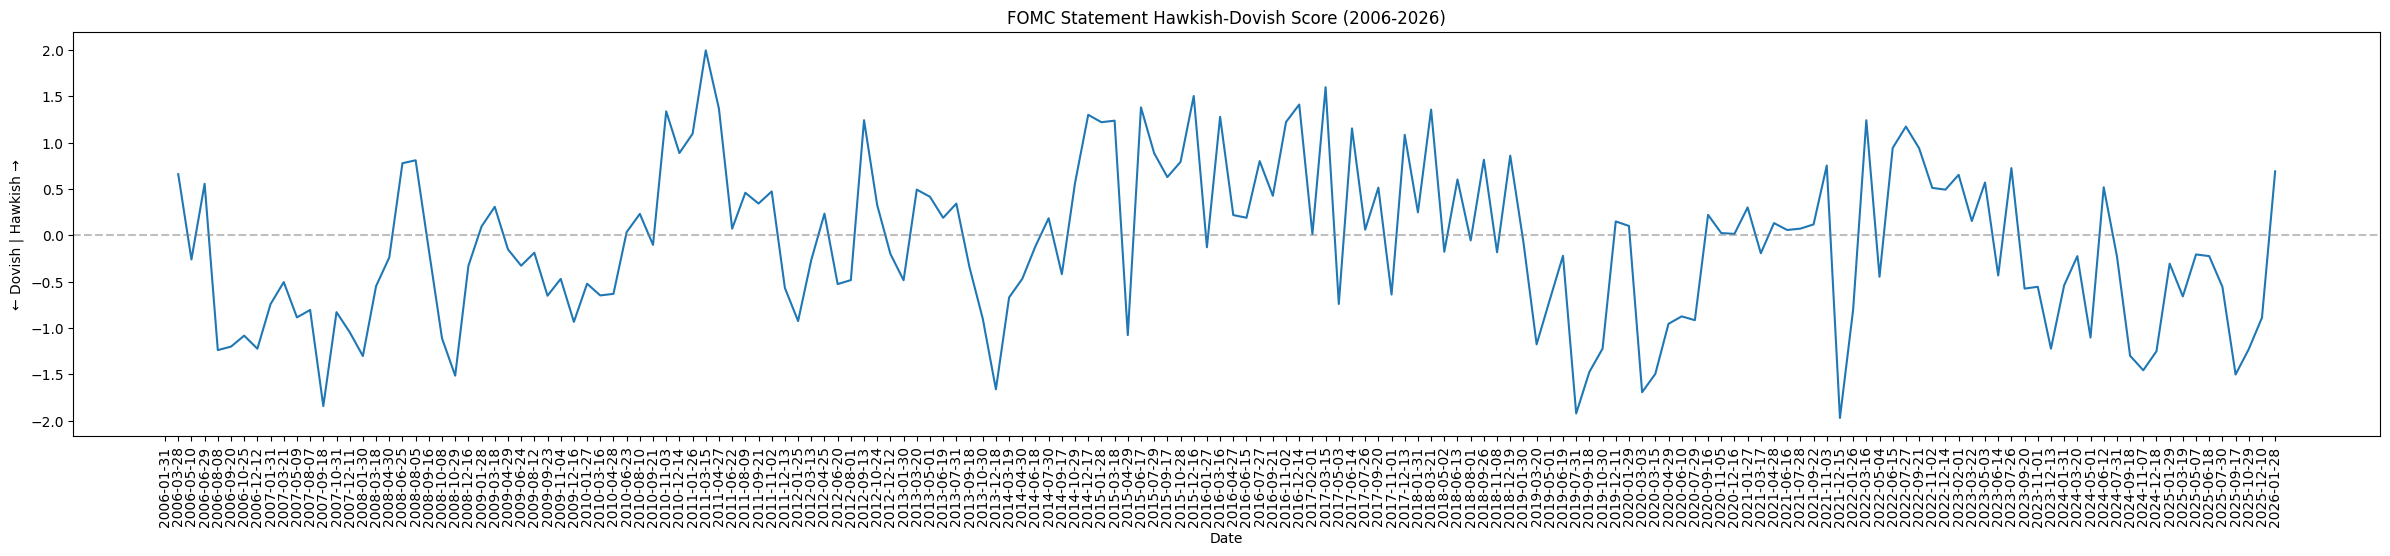

In [12]:
dates = df['date']


# # Expanding window z-scores (no look-ahead bias)
# scores_z = np.zeros(len(scores))
# for i in range(1, len(scores)):
#     historical = scores[:i]
#     scores_z[i] = (scores[i] - np.mean(historical)) / np.std(historical)
# scores_z[0] = 0  # first meeting has no history

# span =15 roughly 2 years
ewm = pd.Series(scores).ewm(span=15).mean()
ewm_std = pd.Series(scores).ewm(span=15).std()
scores_z = (scores - ewm) / ewm_std
plt.figure(figsize=(24, 5))
plt.plot(dates, scores_z)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel("Date")
plt.ylabel("← Dovish | Hawkish →")
plt.title("FOMC Statement Hawkish-Dovish Score (2006-2026)")
plt.tight_layout()
plt.xticks(rotation=90)
plt.show()

In [13]:


# Create hawk-dove DataFrame
hawk_dove_df = pd.DataFrame({
    'date': dates,
    'hawk_dove_score': scores,
    'hawk_dove_zscore': scores_z
})

# Save to pickle
hawk_dove_df.to_pickle('hawk_dove_scores.pkl')
print(f"✓ Saved {len(hawk_dove_df)} records to hawk_dove_scores.pkl")

# Display first few rows
hawk_dove_df.head()

✓ Saved 161 records to hawk_dove_scores.pkl


,date,hawk_dove_score,hawk_dove_zscore
0,2006-01-31,0.016180,NaN
1,2006-03-28,0.052381,0.659966
2,2006-05-10,0.027922,-0.260292
3,2006-06-29,0.045139,0.555890
4,2006-08-08,-0.001524,-1.238244


In [14]:
from sklearn.metrics.pairwise import cosine_similarity

drifts = []
for i in range(1, len(embeddings)):
    sim = cosine_similarity([embeddings[i-1]], [embeddings[i]])[0][0]
    drifts.append(1 - sim)  # distance, not similarity

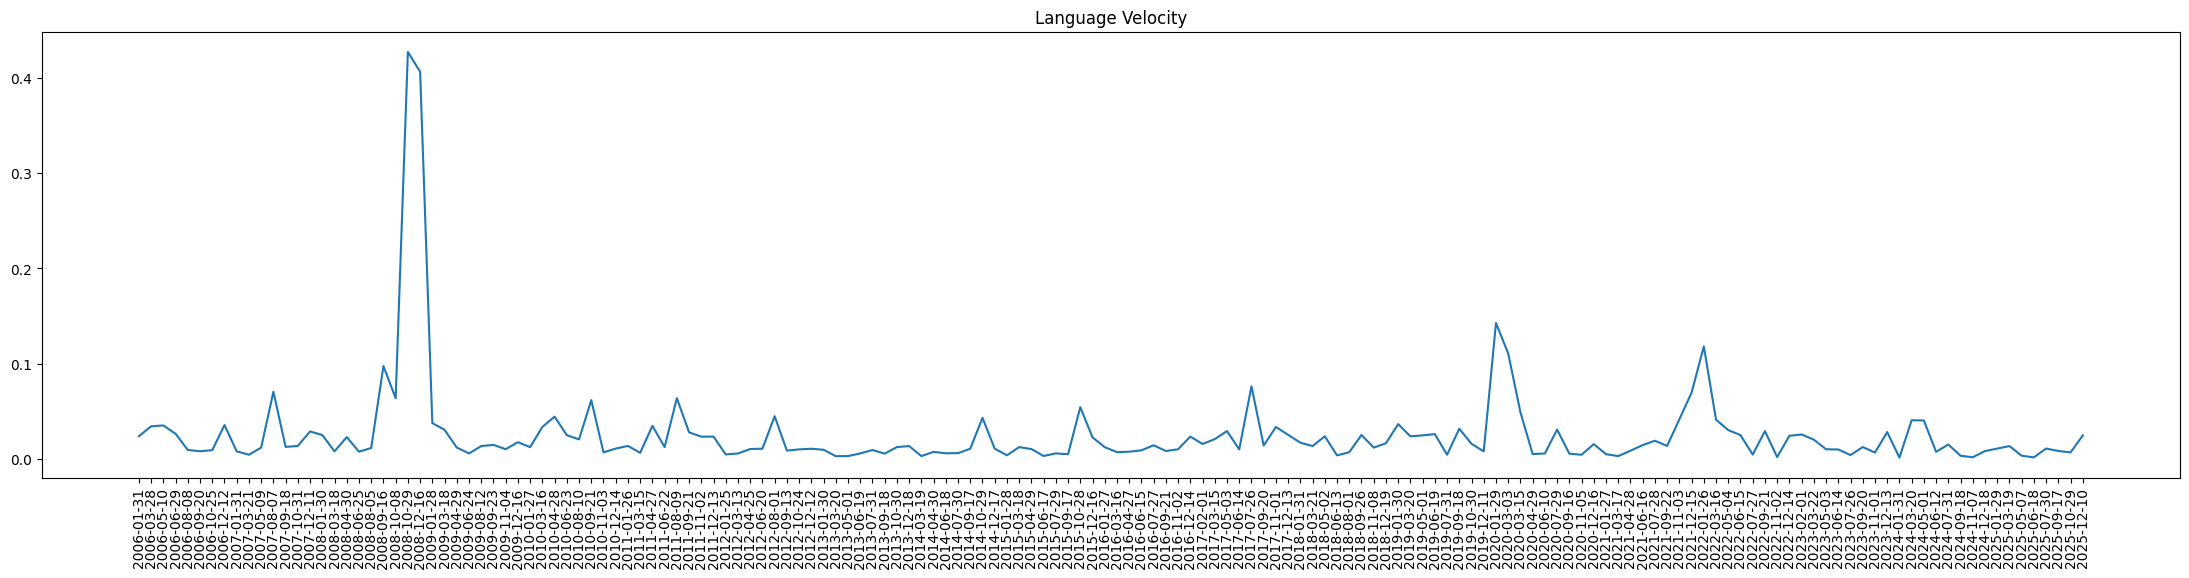

In [15]:
plt.figure(figsize=(22, 5))
plt.plot(dates[:len(dates) - 1], drifts) 
plt.tight_layout()
plt.xticks(rotation=90)
plt.title("Language Velocity")
plt.show()

In [16]:
from dotenv import load_dotenv 
load_dotenv() 

FRED_API_KEY = os.getenv('FRED_API_KEY') 
hawk_dove_df

,date,hawk_dove_score,hawk_dove_zscore
0,2006-01-31,0.016180,NaN
1,2006-03-28,0.052381,0.659966
2,2006-05-10,0.027922,-0.260292
3,2006-06-29,0.045139,0.555890
4,2006-08-08,-0.001524,-1.238244
...,...,...,...
156,2025-07-30,-0.095233,-0.555364
157,2025-09-17,-0.130632,-1.501578
158,2025-10-29,-0.130485,-1.227743
159,2025-12-10,-0.123926,-0.888542


In [17]:

import matplotlib.dates as mdates
from scipy import stats
from statsmodels.tsa.stattools import grangercausalitytests
from fredapi import Fred


def get_fed_funds_rate(api_key: str, start: str = "2006-01-01", end: str = "2026-03-01") -> pd.Series:
    """
    Pull daily effective federal funds rate (DFF) from FRED.
    Returns a daily Series indexed by date.
    """
    fred = Fred(api_key=api_key)
    dff = fred.get_series("DFF", observation_start=start, observation_end=end)
    dff.name = "fed_funds_rate"
    dff.index = pd.to_datetime(dff.index)
    return dff


def get_target_rate(api_key: str, start: str = "2006-01-01", end: str = "2026-03-01") -> pd.Series:
    """
    Pull upper bound of target range (DFEDTARU) from FRED.
    Falls back to DFEDTAR for pre-2008 if needed.
    Useful as an alternative to effective rate.
    """
    fred = Fred(api_key=api_key)
    
    # Upper bound (post-Dec 2008)
    try:
        taru = fred.get_series("DFEDTARU", observation_start=start, observation_end=end)
    except:
        taru = pd.Series(dtype=float)
    
    # Single target (pre-Dec 2008)
    try:
        tar = fred.get_series("DFEDTAR", observation_start=start, observation_end=end)
    except:
        tar = pd.Series(dtype=float)
    
    # Combine: use single target pre-2008, upper bound post-2008
    combined = pd.concat([tar, taru]).sort_index()
    combined = combined[~combined.index.duplicated(keep="last")]
    combined.name = "target_rate"
    combined.index = pd.to_datetime(combined.index)
    return combined


# ─────────────────────────────────────────────
# 2. MAP RATES TO FOMC MEETINGS
# ─────────────────────────────────────────────

def map_rate_to_meetings(
    meeting_dates: list[str],
    rate_series: pd.Series,
    lookback_days: int = 5
) -> pd.DataFrame:
    """
    For each FOMC meeting date, find the effective rate on that date.
    If market was closed, look back up to `lookback_days`.
    
    Args:
        meeting_dates: List of FOMC statement dates (YYYY-MM-DD)
        rate_series: Daily fed funds rate from FRED
        lookback_days: How far back to look if exact date is missing
    
    Returns:
        DataFrame with columns: [date, rate, delta_rate]
    """
    records = []
    
    for date_str in sorted(meeting_dates):
        date = pd.Timestamp(date_str)
        
        # Find nearest available rate (look back up to N days)
        rate = None
        for offset in range(lookback_days + 1):
            lookup = date - pd.Timedelta(days=offset)
            if lookup in rate_series.index:
                rate = rate_series.loc[lookup]
                break
        
        records.append({"date": date, "rate": rate})
    
    df = pd.DataFrame(records)
    df["delta_rate"] = df["rate"].diff()       # meeting-over-meeting change
    df["delta_rate_bps"] = df["delta_rate"] * 100  # in basis points
    
    return df


# ─────────────────────────────────────────────
# 3. MERGE HAWK-DOVE SCORES WITH RATE DATA
# ─────────────────────────────────────────────

def build_analysis_df(
    hawk_dove_df: pd.DataFrame,
    rate_df: pd.DataFrame
) -> pd.DataFrame:
    """
    Merge hawk-dove scores with rate data on meeting dates.
    
    Expects:
        hawk_dove_df: DataFrame with columns [date, hawk_dove_score, hawk_dove_zscore]
        rate_df: DataFrame from map_rate_to_meetings()
    
    Returns:
        Merged DataFrame aligned on meeting dates.
    """
    # Normalize date columns
    hawk_dove_df = hawk_dove_df.copy()
    rate_df = rate_df.copy()
    hawk_dove_df["date"] = pd.to_datetime(hawk_dove_df["date"])
    rate_df["date"] = pd.to_datetime(rate_df["date"])
    
    merged = pd.merge(hawk_dove_df, rate_df, on="date", how="inner")
    merged = merged.sort_values("date").reset_index(drop=True)
    
    print(f"Merged {len(merged)} meetings with both scores and rates")
    print(f"Date range: {merged['date'].min().date()} to {merged['date'].max().date()}")
    
    return merged


# ─────────────────────────────────────────────
# 4. CROSS-CORRELATION ANALYSIS
# ─────────────────────────────────────────────

def compute_cross_correlations(
    df: pd.DataFrame,
    score_col: str = "hawk_dove_zscore",
    rate_col: str = "delta_rate_bps",
    max_lag: int = 6
) -> pd.DataFrame:
    """
    Compute cross-correlation between hawk-dove score at time t
    and rate change at time t+k, for k = -max_lag to +max_lag.
    
    Positive lag = score LEADS rate change (what we want to find)
    Negative lag = score LAGS rate change (reactive language)
    
    Returns DataFrame with lag, correlation, p-value, and significance.
    """
    score = df[score_col].values
    rate = df[rate_col].values
    
    # Drop NaN rows (first meeting has no delta)
    mask = ~(np.isnan(score) | np.isnan(rate))
    score = score[mask]
    rate = rate[mask]
    
    results = []
    n = len(score)
    
    for lag in range(-max_lag, max_lag + 1):
        if lag > 0:
            # Score leads: score[:-lag] vs rate[lag:]
            s = score[:n - lag]
            r = rate[lag:]
        elif lag < 0:
            # Score lags: score[-lag:] vs rate[:n + lag]
            s = score[-lag:]
            r = rate[:n + lag]
        else:
            s = score
            r = rate
        
        corr, pval = stats.pearsonr(s, r)
        n_obs = len(s)
        
        results.append({
            "lag": lag,
            "correlation": corr,
            "p_value": pval,
            "n_obs": n_obs,
            "significant_5pct": pval < 0.05,
            "significant_10pct": pval < 0.10,
            "interpretation": (
                f"Score leads rate by {lag} meetings" if lag > 0
                else f"Score lags rate by {abs(lag)} meetings" if lag < 0
                else "Contemporaneous"
            )
        })
    
    results_df = pd.DataFrame(results)
    
    # Highlight the key finding
    best_lead = results_df[results_df["lag"] > 0].sort_values("correlation", ascending=False).iloc[0]
    print(f"\n{'='*60}")
    print(f"CROSS-CORRELATION RESULTS")
    print(f"{'='*60}")
    print(f"Strongest leading correlation: lag={int(best_lead['lag'])} meetings")
    print(f"  r = {best_lead['correlation']:.4f}, p = {best_lead['p_value']:.4f}")
    print(f"  {'✓ Significant at 5%' if best_lead['significant_5pct'] else '✗ Not significant at 5%'}")
    print(f"{'='*60}\n")
    
    return results_df


# ─────────────────────────────────────────────
# 5. GRANGER CAUSALITY
# ─────────────────────────────────────────────

def run_granger_tests(
    df: pd.DataFrame,
    score_col: str = "hawk_dove_zscore",
    rate_col: str = "delta_rate_bps",
    max_lag: int = 4
) -> dict:
    """
    Granger causality test: does hawk-dove score Granger-cause rate changes?
    
    Tests whether past values of hawk_dove_score improve prediction of
    delta_rate beyond what past values of delta_rate alone provide.
    
    Returns dict with test results per lag.
    """
    # Prepare 2-column DataFrame (dependent var first for statsmodels convention)
    test_df = df[[rate_col, score_col]].dropna().copy()
    
    print(f"\n{'='*60}")
    print(f"GRANGER CAUSALITY TESTS")
    print(f"H0: Hawk-dove score does NOT Granger-cause rate changes")
    print(f"{'='*60}")
    
    try:
        results = grangercausalitytests(test_df, maxlag=max_lag, verbose=False)
        
        summary = {}
        for lag in range(1, max_lag + 1):
            f_test = results[lag][0]["ssr_ftest"]
            f_stat, p_val = f_test[0], f_test[1]
            
            summary[lag] = {
                "f_statistic": f_stat,
                "p_value": p_val,
                "significant_5pct": p_val < 0.05,
                "significant_10pct": p_val < 0.10
            }
            
            sig_marker = "✓✓" if p_val < 0.05 else "✓" if p_val < 0.10 else "✗"
            print(f"  Lag {lag}: F={f_stat:.3f}, p={p_val:.4f}  {sig_marker}")
        
        print(f"{'='*60}\n")
        return summary
        
    except Exception as e:
        print(f"  Granger test failed: {e}")
        print(f"  (Common cause: too few observations for the requested lag)")
        return {}


# ─────────────────────────────────────────────
# 6. PREDICTIVE REGIME CLASSIFICATION
# ─────────────────────────────────────────────

def regime_prediction_accuracy(
    df: pd.DataFrame,
    score_col: str = "hawk_dove_zscore",
    rate_col: str = "delta_rate_bps",
    lead: int = 1
) -> dict:
    """
    Simple test: does the SIGN of the hawk-dove score at meeting t
    predict the DIRECTION of rate change at meeting t+lead?
    
    hawk_dove > 0 → predict hike (delta > 0)
    hawk_dove < 0 → predict cut  (delta < 0)
    hawk_dove ≈ 0 → predict hold (delta = 0)
    
    Returns accuracy metrics.
    """
    score = df[score_col].values
    rate = df[rate_col].values
    
    # Align: score at t, rate change at t+lead
    score_aligned = score[:len(score) - lead]
    rate_aligned = rate[lead:]
    
    # Drop NaNs
    mask = ~(np.isnan(score_aligned) | np.isnan(rate_aligned))
    score_aligned = score_aligned[mask]
    rate_aligned = rate_aligned[mask]
    
    # Classify
    # Rate: hike (>5bps), cut (<-5bps), hold (within ±5bps)
    actual_direction = np.where(rate_aligned > 5, 1, np.where(rate_aligned < -5, -1, 0))
    
    # Score: hawkish (>0.5), dovish (<-0.5), neutral
    predicted_direction = np.where(score_aligned > 0.5, 1, np.where(score_aligned < -0.5, -1, 0))
    
    correct = np.sum(actual_direction == predicted_direction)
    total = len(actual_direction)
    accuracy = correct / total
    
    # Direction-only accuracy (ignoring holds)
    move_mask = actual_direction != 0
    if move_mask.sum() > 0:
        move_accuracy = np.sum(
            actual_direction[move_mask] == predicted_direction[move_mask]
        ) / move_mask.sum()
    else:
        move_accuracy = np.nan
    
    result = {
        "lead_meetings": lead,
        "total_meetings": total,
        "accuracy_all": accuracy,
        "accuracy_moves_only": move_accuracy,
        "n_hikes": int((actual_direction == 1).sum()),
        "n_cuts": int((actual_direction == -1).sum()),
        "n_holds": int((actual_direction == 0).sum()),
    }
    
    print(f"\nREGIME PREDICTION (lead={lead} meeting(s)):")
    print(f"  Overall accuracy:    {accuracy:.1%} ({correct}/{total})")
    print(f"  Move-only accuracy:  {move_accuracy:.1%}")
    print(f"  (Hikes: {result['n_hikes']}, Cuts: {result['n_cuts']}, Holds: {result['n_holds']})")
    
    return result


# ─────────────────────────────────────────────
# 7. VISUALIZATION
# ─────────────────────────────────────────────

def plot_cross_correlation(xcorr_df: pd.DataFrame, save_path: str = None):
    """Bar chart of cross-correlations at each lag."""
    fig, ax = plt.subplots(figsize=(12, 5))
    
    colors = [
        "#2ecc71" if row["significant_5pct"] and row["lag"] > 0
        else "#e74c3c" if row["significant_5pct"] and row["lag"] < 0
        else "#f39c12" if row["significant_10pct"]
        else "#bdc3c7"
        for _, row in xcorr_df.iterrows()
    ]
    
    ax.bar(xcorr_df["lag"], xcorr_df["correlation"], color=colors, edgecolor="white", width=0.7)
    ax.axhline(y=0, color="black", linewidth=0.5)
    ax.axvline(x=0, color="black", linewidth=0.5, linestyle="--", alpha=0.3)
    
    # Significance threshold (approximate for n~150)
    n = xcorr_df["n_obs"].iloc[0]
    sig_threshold = 1.96 / np.sqrt(n)
    ax.axhline(y=sig_threshold, color="gray", linestyle="--", alpha=0.5, label=f"95% CI (±{sig_threshold:.3f})")
    ax.axhline(y=-sig_threshold, color="gray", linestyle="--", alpha=0.5)
    
    ax.set_xlabel("Lag (meetings)", fontsize=12)
    ax.set_ylabel("Pearson Correlation", fontsize=12)
    ax.set_title("Cross-Correlation: Hawk-Dove Score vs. Rate Change\n(Positive lag = score LEADS rate)", fontsize=13)
    ax.legend(fontsize=10)
    ax.set_xticks(xcorr_df["lag"])
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved: {save_path}")
    plt.show()


def plot_overlay(
    df: pd.DataFrame,
    score_col: str = "hawk_dove_zscore",
    rate_col: str = "rate",
    optimal_lead: int = 1,
    save_path: str = None
):
    """
    Dual-axis plot: hawk-dove z-score (shifted forward by optimal_lead)
    overlaid on the fed funds rate path.
    
    This is the money chart — visually shows the score predicting rate moves.
    """
    fig, ax1 = plt.subplots(figsize=(16, 7))
    
    dates = pd.to_datetime(df["date"])
    rate = df[rate_col]
    score = df[score_col]
    
    # Plot rate on primary axis
    ax1.plot(dates, rate, color="#2c3e50", linewidth=2, label="Fed Funds Rate (%)", zorder=3)
    ax1.fill_between(dates, 0, rate, alpha=0.1, color="#2c3e50")
    ax1.set_ylabel("Fed Funds Rate (%)", fontsize=12, color="#2c3e50")
    ax1.tick_params(axis="y", labelcolor="#2c3e50")
    
    # Plot hawk-dove score on secondary axis, SHIFTED FORWARD
    ax2 = ax1.twinx()
    
    # Shift score forward by optimal_lead meetings
    shifted_dates = dates.iloc[optimal_lead:].values
    shifted_score = score.iloc[:-optimal_lead].values if optimal_lead > 0 else score.values
    
    ax2.plot(shifted_dates, shifted_score, color="#e74c3c", linewidth=1.5, alpha=0.8,
             label=f"Hawk-Dove Score (shifted +{optimal_lead} meeting{'s' if optimal_lead > 1 else ''})")
    ax2.fill_between(shifted_dates, 0, shifted_score, 
                     where=shifted_score > 0, alpha=0.15, color="#e74c3c", label="_hawkish")
    ax2.fill_between(shifted_dates, 0, shifted_score,
                     where=shifted_score < 0, alpha=0.15, color="#3498db", label="_dovish")
    ax2.axhline(y=0, color="#e74c3c", linewidth=0.5, linestyle="--", alpha=0.3)
    ax2.set_ylabel("Hawk-Dove Z-Score (shifted)", fontsize=12, color="#e74c3c")
    ax2.tick_params(axis="y", labelcolor="#e74c3c")
    
    # Annotate key events
    events = {
        "2008-12-16": "GFC\nZero Bound",
        "2015-12-16": "First Hike\nPost-GFC",
        "2020-03-15": "COVID\nEmergency Cut",
        "2022-03-16": "Inflation\nHike Cycle",
    }
    for date_str, label in events.items():
        event_date = pd.Timestamp(date_str)
        if dates.min() <= event_date <= dates.max():
            ax1.axvline(x=event_date, color="gray", linewidth=0.8, linestyle=":", alpha=0.5)
            ax1.annotate(label, xy=(event_date, ax1.get_ylim()[1] * 0.9),
                        fontsize=8, ha="center", color="gray",
                        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    # Formatting
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax1.xaxis.set_major_locator(mdates.YearLocator(2))
    ax1.set_xlabel("Date", fontsize=12)
    ax1.set_title(
        f"Fed Communications Analyzer: Language Leads Policy by {optimal_lead} Meeting{'s' if optimal_lead > 1 else ''}\n"
        f"Hawk-Dove Score (shifted +{optimal_lead}) vs. Fed Funds Rate",
        fontsize=14, fontweight="bold"
    )
    
    # Combined legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=10)
    
    ax1.grid(True, alpha=0.2)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved: {save_path}")
    plt.show()


# ─────────────────────────────────────────────
# 8. MAIN PIPELINE
# ─────────────────────────────────────────────

def run_lead_lag_analysis(
    hawk_dove_df: pd.DataFrame,
    fred_api_key: str,
    max_lag: int = 6,
    output_dir: str = "outputs"
):
    """
    Full pipeline:
      1. Pull rate data from FRED
      2. Map to FOMC meetings
      3. Cross-correlate at multiple lags
      4. Granger causality tests
      5. Regime prediction accuracy
      6. Generate all plots
    
    Args:
        hawk_dove_df: DataFrame with columns [date, hawk_dove_score, hawk_dove_zscore]
                      (output from your existing embedding pipeline)
        fred_api_key: Your FRED API key
        max_lag: Maximum lag to test (in meetings)
        output_dir: Where to save plots
    """
    os.makedirs(output_dir, exist_ok=True)
    
    print("=" * 60)
    print("FED COMMUNICATIONS ANALYZER - LEAD/LAG ANALYSIS")
    print("=" * 60)
    
    # --- Step 1: Get rate data ---
    print("\n[1/6] Pulling fed funds rate from FRED...")
    rate_series = get_fed_funds_rate(fred_api_key)
    print(f"  Got {len(rate_series)} daily observations")
    print(f"  Range: {rate_series.index.min().date()} to {rate_series.index.max().date()}")
    
    # --- Step 2: Map to meetings ---
    print("\n[2/6] Mapping rates to FOMC meeting dates...")
    meeting_dates = hawk_dove_df["date"].tolist()
    rate_df = map_rate_to_meetings(meeting_dates, rate_series)
    print(f"  Mapped {len(rate_df)} meetings")
    
    # --- Step 3: Merge ---
    print("\n[3/6] Merging hawk-dove scores with rate data...")
    analysis_df = build_analysis_df(hawk_dove_df, rate_df)
    
    # --- Step 4: Cross-correlation ---
    print("\n[4/6] Computing cross-correlations...")
    xcorr_df = compute_cross_correlations(analysis_df, max_lag=max_lag)
    print(xcorr_df[["lag", "correlation", "p_value", "significant_5pct"]].to_string(index=False))
    
    # --- Step 5: Granger causality ---
    print("\n[5/6] Running Granger causality tests...")
    granger_results = run_granger_tests(analysis_df, max_lag=min(max_lag, 4))
    
    # --- Step 6: Regime prediction ---
    print("\n[6/6] Testing regime prediction accuracy...")
    regime_results = {}
    for lead in [1, 2, 3]:
        regime_results[lead] = regime_prediction_accuracy(analysis_df, lead=lead)
    
    # --- Plots ---
    print("\n\nGenerating plots...")
    
    # Find optimal lead (highest significant positive-lag correlation)
    positive_lags = xcorr_df[xcorr_df["lag"] > 0]
    if positive_lags["significant_10pct"].any():
        optimal_lead = int(positive_lags.loc[
            positive_lags[positive_lags["significant_10pct"]]["correlation"].idxmax(), "lag"
        ])
    else:
        optimal_lead = 1  # default
    
    print(f"  Optimal lead: {optimal_lead} meeting(s)")
    
    plot_cross_correlation(xcorr_df, save_path=os.path.join(output_dir, "cross_correlation.png"))
    plot_overlay(analysis_df, optimal_lead=optimal_lead, 
                 save_path=os.path.join(output_dir, "lead_lag_overlay.png"))
    
    # --- Summary ---
    print("\n" + "=" * 60)
    print("SUMMARY")
    print("=" * 60)
    print(f"Optimal lead: {optimal_lead} meeting(s)")
    
    best = xcorr_df.loc[xcorr_df["lag"] == optimal_lead].iloc[0]
    print(f"Cross-correlation at optimal lead: r={best['correlation']:.4f} (p={best['p_value']:.4f})")
    
    if optimal_lead in granger_results:
        g = granger_results[optimal_lead]
        print(f"Granger causality at lag {optimal_lead}: F={g['f_statistic']:.3f} (p={g['p_value']:.4f})")
    
    if optimal_lead in regime_results:
        r = regime_results[optimal_lead]
        print(f"Regime prediction accuracy: {r['accuracy_all']:.1%} (all), {r['accuracy_moves_only']:.1%} (moves only)")
    
    print("=" * 60)
    
    return {
        "analysis_df": analysis_df,
        "xcorr_df": xcorr_df,
        "granger_results": granger_results,
        "regime_results": regime_results,
        "optimal_lead": optimal_lead,
    }


FED COMMUNICATIONS ANALYZER - LEAD/LAG ANALYSIS

[1/6] Pulling fed funds rate from FRED...
  Got 7363 daily observations
  Range: 2006-01-01 to 2026-02-27

[2/6] Mapping rates to FOMC meeting dates...
  Mapped 161 meetings

[3/6] Merging hawk-dove scores with rate data...
Merged 161 meetings with both scores and rates
Date range: 2006-01-31 to 2026-01-28

[4/6] Computing cross-correlations...

CROSS-CORRELATION RESULTS
Strongest leading correlation: lag=1 meetings
  r = 0.4686, p = 0.0000
  ✓ Significant at 5%

 lag  correlation      p_value  significant_5pct
  -6     0.069096 3.944961e-01             False
  -5     0.086502 2.845170e-01             False
  -4     0.023423 7.716311e-01             False
  -3     0.055378 4.909074e-01             False
  -2     0.093411 2.430528e-01             False
  -1     0.221455 5.026582e-03              True
   0     0.311713 6.010263e-05              True
   1     0.468576 4.696826e-10              True
   2     0.300448 1.252653e-04            

C:\Users\Jay\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


Saved: outputs\cross_correlation.png


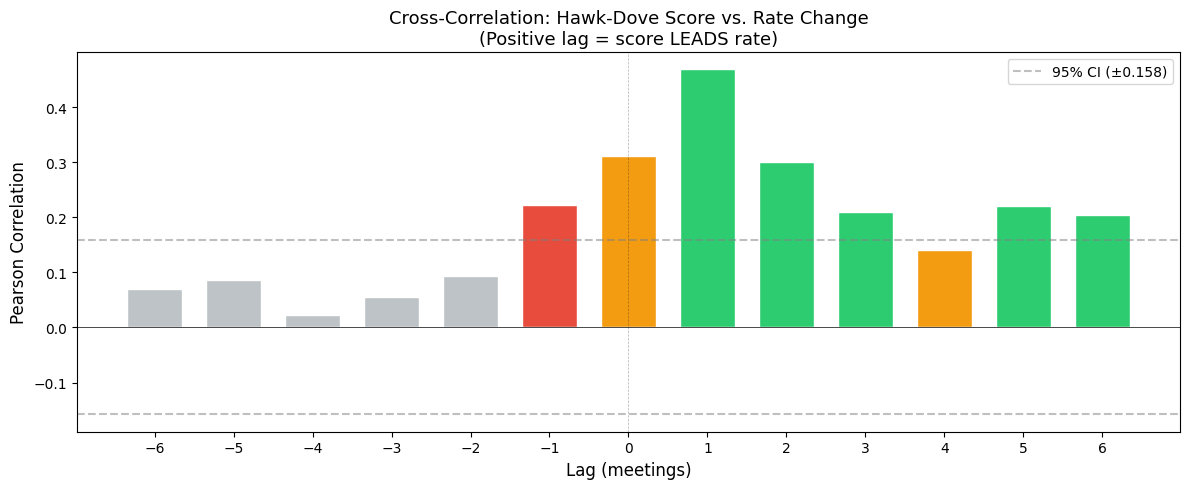

Saved: outputs\lead_lag_overlay.png


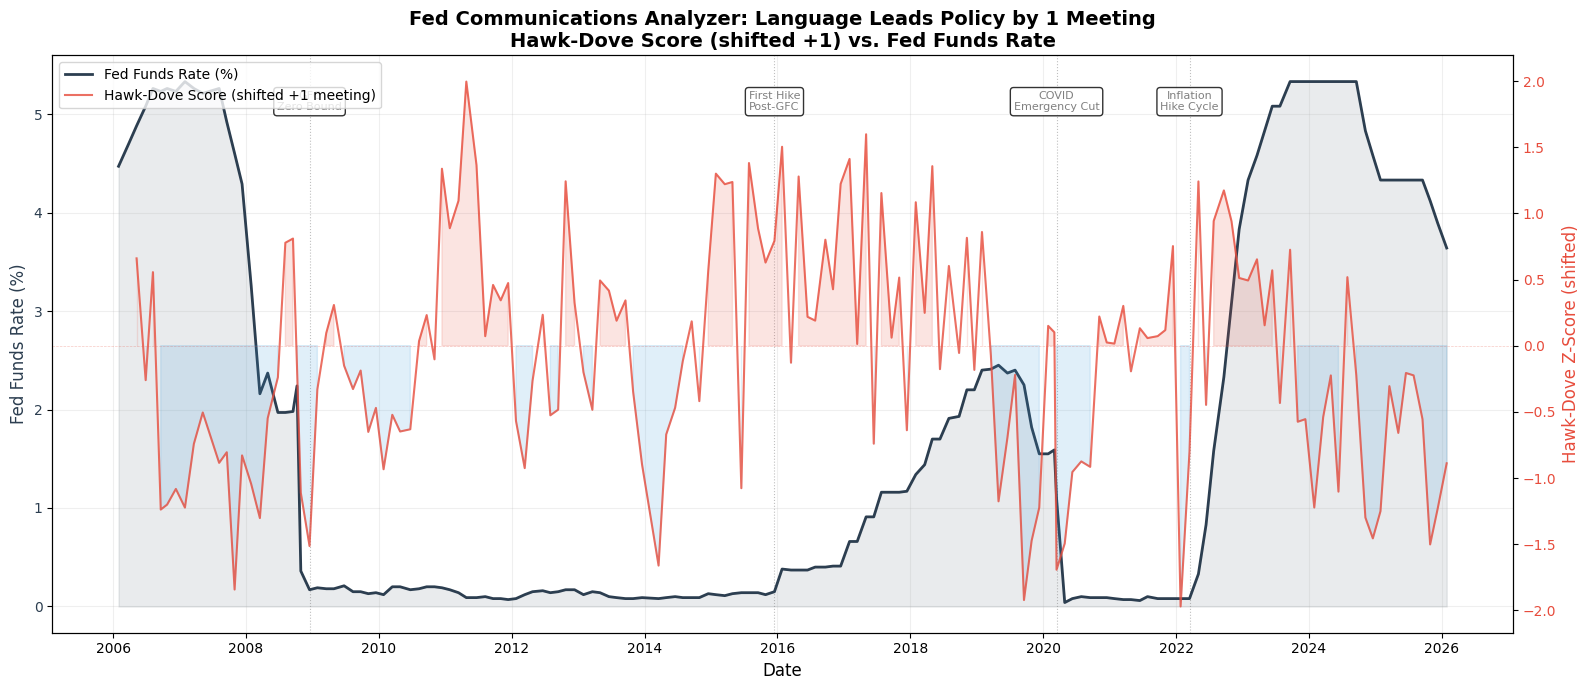


SUMMARY
Optimal lead: 1 meeting(s)
Cross-correlation at optimal lead: r=0.4686 (p=0.0000)
Granger causality at lag 1: F=28.091 (p=0.0000)
Regime prediction accuracy: 59.1% (all), 75.0% (moves only)


{'analysis_df':           date  hawk_dove_score  hawk_dove_zscore  rate  delta_rate  \
 0   2006-01-31         0.016180               NaN  4.47         NaN   
 1   2006-03-28         0.052381          0.659966  4.70        0.23   
 2   2006-05-10         0.027922         -0.260292  4.88        0.18   
 3   2006-06-29         0.045139          0.555890  5.08        0.20   
 4   2006-08-08        -0.001524         -1.238244  5.26        0.18   
 ..         ...              ...               ...   ...         ...   
 156 2025-07-30        -0.095233         -0.555364  4.33        0.00   
 157 2025-09-17        -0.130632         -1.501578  4.33        0.00   
 158 2025-10-29        -0.130485         -1.227743  4.12       -0.21   
 159 2025-12-10        -0.123926         -0.888542  3.89       -0.23   
 160 2026-01-28        -0.073490          0.690000  3.64       -0.25   
 
      delta_rate_bps  
 0               NaN  
 1              23.0  
 2              18.0  
 3              20.0  
 4  

In [18]:
run_lead_lag_analysis(hawk_dove_df, FRED_API_KEY)

D:\TEMP\ipykernel_2708\139341061.py:9: RuntimeWarning: divide by zero encountered in scalar divide
  scores_z[i] = (scores[i] - np.mean(historical)) / np.std(historical)


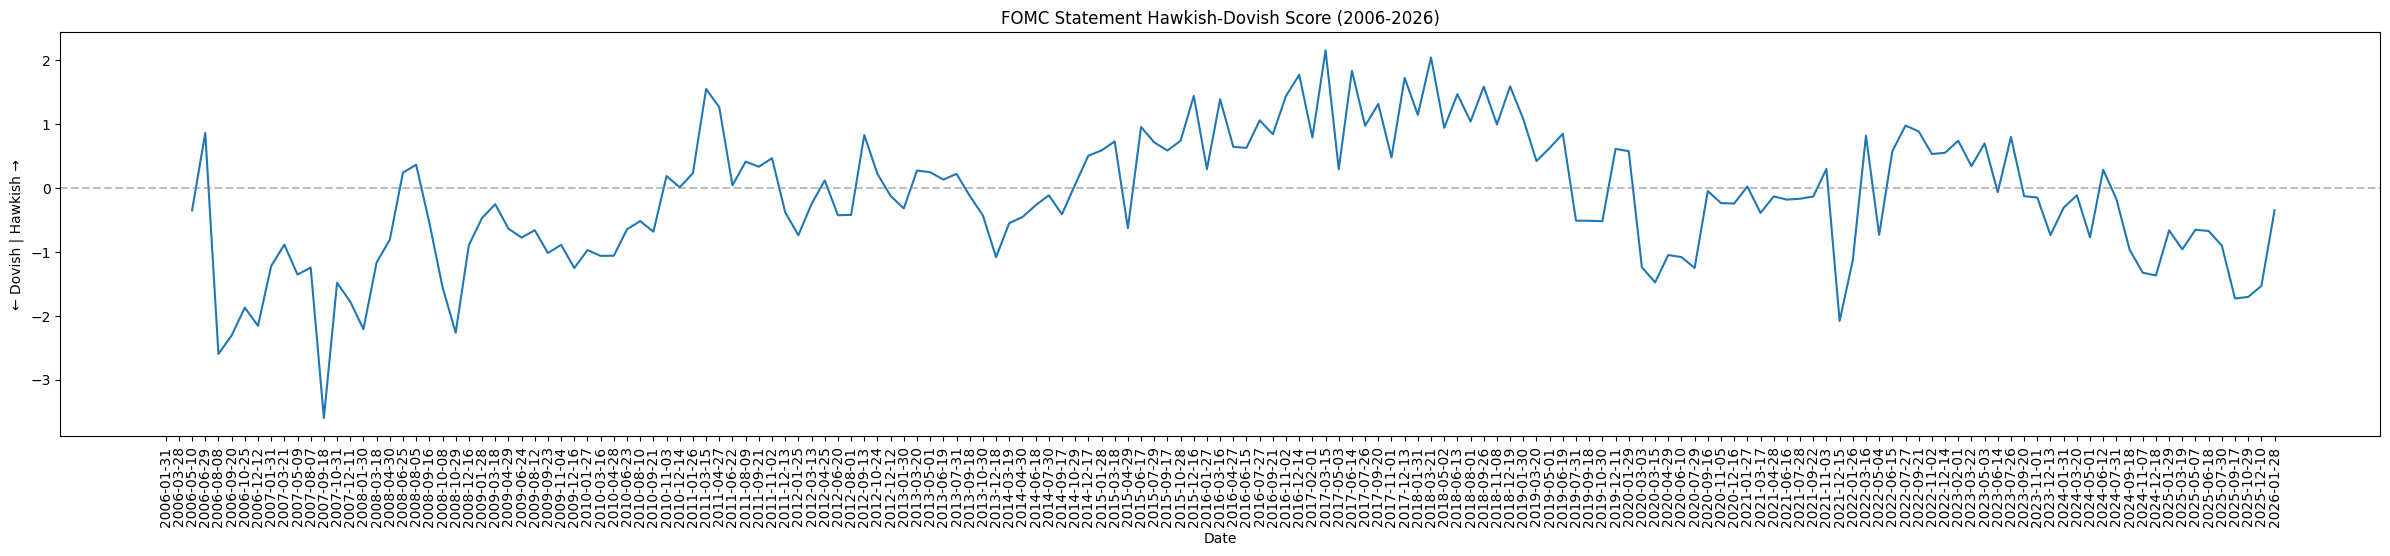

In [19]:
# Expanding Window 
dates = df['date']


# # Expanding window z-scores (no look-ahead bias)
scores_z = np.zeros(len(scores))
for i in range(1, len(scores)):
    historical = scores[:i]
    scores_z[i] = (scores[i] - np.mean(historical)) / np.std(historical)
scores_z[0] = 0  # first meeting has no history

# span =15 roughly 2 years

plt.figure(figsize=(24, 5))
plt.plot(dates, scores_z)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel("Date")
plt.ylabel("← Dovish | Hawkish →")
plt.title("FOMC Statement Hawkish-Dovish Score (2006-2026)")
plt.tight_layout()
plt.xticks(rotation=90)
plt.show()

In [20]:
hawk_dove_df = pd.DataFrame({
    'date': dates,
    'hawk_dove_score': scores,
    'hawk_dove_zscore': scores_z
})

FED COMMUNICATIONS ANALYZER - LEAD/LAG ANALYSIS

[1/6] Pulling fed funds rate from FRED...
  Got 7363 daily observations
  Range: 2006-01-01 to 2026-02-27

[2/6] Mapping rates to FOMC meeting dates...
  Mapped 161 meetings

[3/6] Merging hawk-dove scores with rate data...
Merged 161 meetings with both scores and rates
Date range: 2006-01-31 to 2026-01-28

[4/6] Computing cross-correlations...

CROSS-CORRELATION RESULTS
Strongest leading correlation: lag=1 meetings
  r = nan, p = nan
  ✗ Not significant at 5%

 lag  correlation  p_value  significant_5pct
  -6     0.214346 0.007599              True
  -5     0.206992 0.009760              True
  -4     0.150657 0.060476             False
  -3     0.166218 0.037474              True
  -2     0.210798 0.007847              True
  -1     0.292792 0.000180              True
   0          NaN      NaN             False
   1          NaN      NaN             False
   2          NaN      NaN             False
   3          NaN      NaN         

C:\Users\Jay\AppData\Roaming\Python\Python312\site-packages\scipy\stats\_stats_py.py:4893: RuntimeWarning: invalid value encountered in subtract
  xm = x - xmean


Saved: outputs\cross_correlation.png


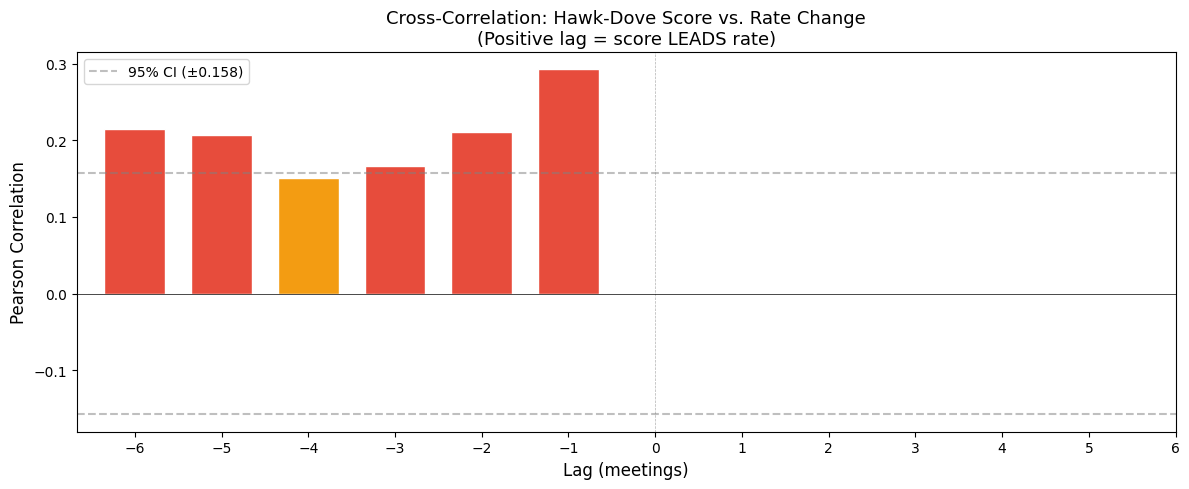

Saved: outputs\lead_lag_overlay.png


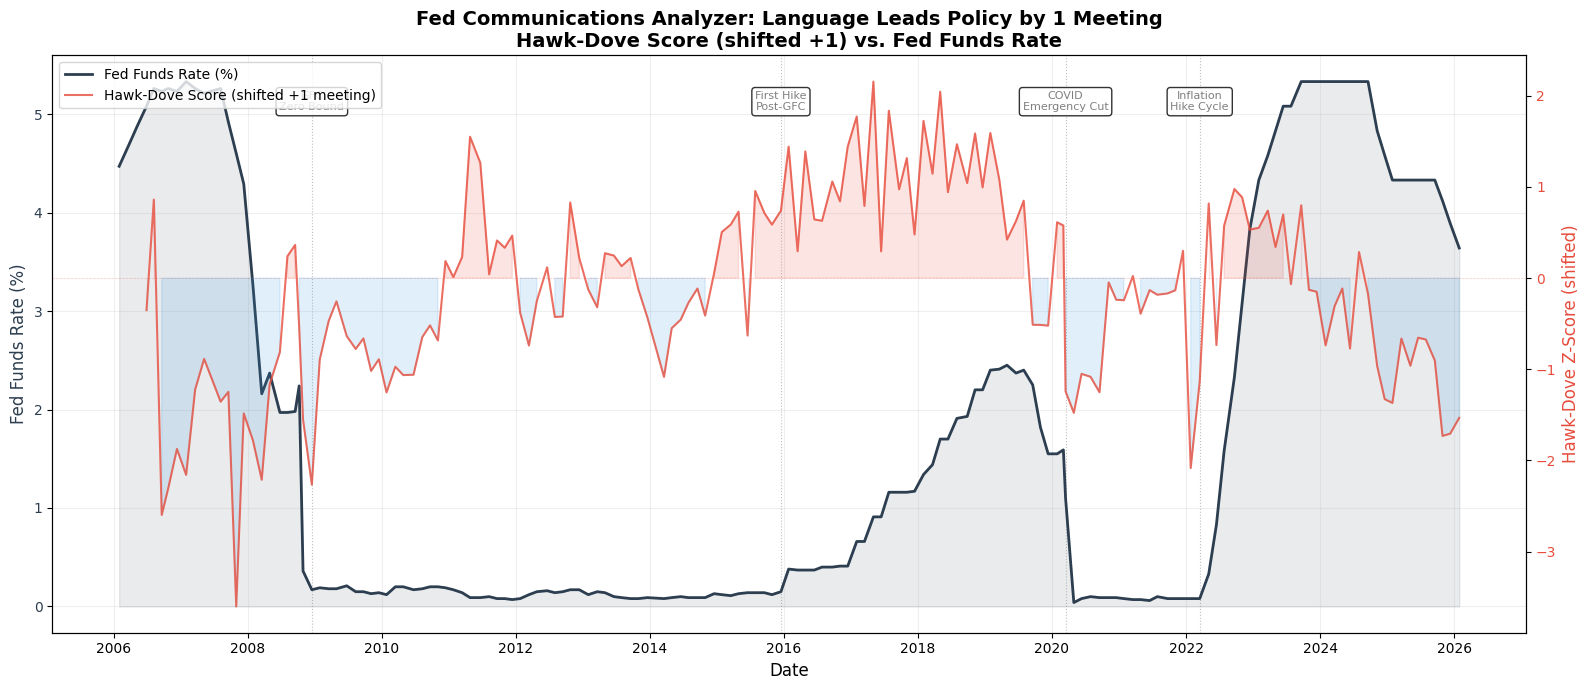


SUMMARY
Optimal lead: 1 meeting(s)
Cross-correlation at optimal lead: r=nan (p=nan)
Regime prediction accuracy: 57.5% (all), 79.2% (moves only)


{'analysis_df':           date  hawk_dove_score  hawk_dove_zscore  rate  delta_rate  \
 0   2006-01-31         0.016180          0.000000  4.47         NaN   
 1   2006-03-28         0.052381               inf  4.70        0.23   
 2   2006-05-10         0.027922         -0.351306  4.88        0.18   
 3   2006-06-29         0.045139          0.860640  5.08        0.20   
 4   2006-08-08        -0.001524         -2.597531  5.26        0.18   
 ..         ...              ...               ...   ...         ...   
 156 2025-07-30        -0.095233         -0.903713  4.33        0.00   
 157 2025-09-17        -0.130632         -1.731040  4.33        0.00   
 158 2025-10-29        -0.130485         -1.705982  4.12       -0.21   
 159 2025-12-10        -0.123926         -1.532857  3.89       -0.23   
 160 2026-01-28        -0.073490         -0.349948  3.64       -0.25   
 
      delta_rate_bps  
 0               NaN  
 1              23.0  
 2              18.0  
 3              20.0  
 4  

In [21]:
run_lead_lag_analysis(hawk_dove_df, FRED_API_KEY)